# Tyre Degradation Fit — Exploratory

Fits the Stage 1 degradation model per compound per circuit and plots fitted curve vs real stint laps.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np

from db.session import SessionLocal, init_db
from db.models import Race, Lap
from app.models.tyre_degradation import fit_degradation, predict_lap_time
from app.models.fuel_model import fuel_correction

In [2]:
init_db()
session = SessionLocal()

CIRCUIT = 'bahrain'
COMPOUND = 'SOFT'

params = fit_degradation(CIRCUIT, COMPOUND, session)
print(params)

{'a': 0.11740755736103964, 'b': 6.818164256826522e-16, 'base_lap_s': 99.105, 'n_laps_fit': 326, 'max_stint_lap_observed': 18, 'fallback': False}


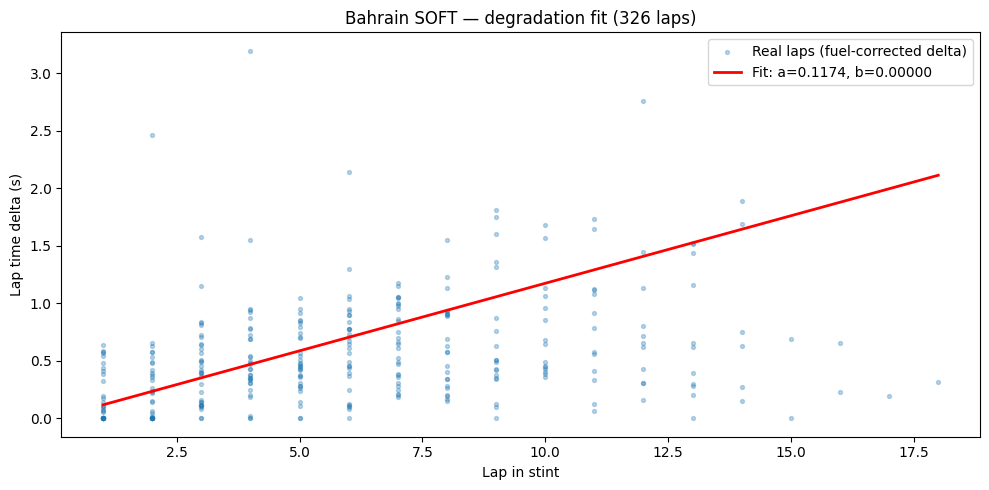

In [3]:
# Plot: scatter of real fuel-corrected stint lap times vs fitted curve
races = session.query(Race).filter(Race.circuit_key == CIRCUIT).all()
scatter_x, scatter_y = [], []

for race in races:
    laps = (
        session.query(Lap)
        .filter(
            Lap.race_id == race.id,
            Lap.compound == COMPOUND,
            Lap.is_valid == True,
            Lap.lap_time_s.isnot(None),
            Lap.stint_number.isnot(None),
        )
        .order_by(Lap.driver, Lap.stint_number, Lap.lap_number)
        .all()
    )
    stints = {}
    for lap in laps:
        stints.setdefault((lap.driver, lap.stint_number), []).append(lap)

    for _, stint_laps in stints.items():
        if len(stint_laps) < 3:
            continue
        core = stint_laps[1:-1]
        corrected = [l.lap_time_s - fuel_correction(l.lap_number) for l in core]
        base = min(corrected)
        for i, t in enumerate(corrected, start=1):
            scatter_x.append(i)
            scatter_y.append(t - base)

lap_range = np.linspace(1, max(scatter_x) if scatter_x else 40, 100)
fitted_y = params['a'] * lap_range + params['b'] * lap_range ** 2

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(scatter_x, scatter_y, alpha=0.3, s=8, label='Real laps (fuel-corrected delta)')
ax.plot(lap_range, fitted_y, color='red', linewidth=2, label=f'Fit: a={params["a"]:.4f}, b={params["b"]:.5f}')
ax.set_xlabel('Lap in stint')
ax.set_ylabel('Lap time delta (s)')
ax.set_title(f'{CIRCUIT.title()} {COMPOUND} — degradation fit ({params["n_laps_fit"]} laps)')
ax.legend()
plt.tight_layout()
plt.show()

session.close()